In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
#warnings.simplefilter('ignore')

In [3]:
books_data=pd.read_csv("Books.csv")
books_data.head()

C:\Users\vijayababu\AppData\Local\Temp\ipykernel_15592\2069433901.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_data=pd.read_csv("Books.csv")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
books_data.info()
books_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


(271360, 8)

In [7]:
users_data=pd.read_csv("Users.csv")
users_data.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [9]:
users_data.info()
users_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


(278858, 3)

In [11]:
ratings_data=pd.read_csv("Ratings.csv")
ratings_data.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [13]:
ratings_data.info()
ratings_data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


(1149780, 3)

In [15]:
# drop the image URLs
books_data.drop(['Image-URL-S','Image-URL-M','Image-URL-L'],axis=1,inplace=True)

In [17]:
# converting feature names to lowercase and replacing '-' with '_'
books_data.columns= books_data.columns.str.strip().str.lower().str.replace('-', '_')
users_data.columns= users_data.columns.str.strip().str.lower().str.replace('-', '_')
ratings_data.columns= ratings_data.columns.str.strip().str.lower().str.replace('-', '_')

In [19]:
books_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   isbn                 271360 non-null  object
 1   book_title           271360 non-null  object
 2   book_author          271358 non-null  object
 3   year_of_publication  271360 non-null  object
 4   publisher            271358 non-null  object
dtypes: object(5)
memory usage: 10.4+ MB


In [21]:
#check for null values in books data
books_data.isnull().sum()

isbn                   0
book_title             0
book_author            2
year_of_publication    0
publisher              2
dtype: int64

In [23]:
# nan values in particular column
books_data.loc[(books_data['book_author'].isnull()),:]

,isbn,book_title,book_author,year_of_publication,publisher
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing


In [25]:
books_data.loc[(books_data['publisher'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN


In [27]:
#replacing 'NaN' with 'unknown'
#books_data.dropna(inplace=True)
#books_data.shape
books_data.loc[(books_data['isbn']=='0751352497'),'book_author']='unknown'
books_data.loc[(books_data['isbn']=='9627982032'),'book_author']='unknown'
books_data.loc[(books_data['isbn']=='193169656X'),'publisher']='unknown'
books_data.loc[(books_data['isbn']=='1931696993'),'publisher']='unknown'
books_data.isnull().sum()

isbn                   0
book_title             0
book_author            0
year_of_publication    0
publisher              0
dtype: int64

In [29]:
# unique values for 'year_of_publication' feature
books_data['year_of_publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

In [31]:
# extracting and fixing mismatch in feature values 'year_of_publication','publisher','book_author'
books_data[books_data['year_of_publication']=='DK Publishing Inc']

,isbn,book_title,book_author,year_of_publication,publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


In [33]:
books_data[books_data['year_of_publication']=='Gallimard']

,isbn,book_title,book_author,year_of_publication,publisher
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...


In [35]:
#correcting these records
# function to fix mismatch data in feature 'book_title', 'book_author', ' year_of_publication', 'publisher'
def replace_df_value(df, idx, col_name, val):
    df.loc[idx, col_name] = val
    return df

In [37]:
replace_df_value(books_data, 209538, 'book_title', 'DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)')
replace_df_value(books_data, 209538, 'book_author', 'Michael Teitelbaum')
replace_df_value(books_data, 209538, 'year_of_publication', 2000)
replace_df_value(books_data, 209538, 'publisher', 'DK Publishing Inc')

replace_df_value(books_data, 221678, 'book_title', 'DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)')
replace_df_value(books_data, 221678, 'book_author', 'James Buckley')
replace_df_value(books_data, 221678, 'year_of_publication', 2000)
replace_df_value(books_data, 221678, 'publisher', 'DK Publishing Inc')

replace_df_value(books_data, 220731,'book_title', "Peuple du ciel, suivi de 'Les Bergers")
replace_df_value(books_data, 220731, 'book_author', 'Jean-Marie Gustave Le ClÃ?Â©zio')
replace_df_value(books_data, 220731, 'year_of_publication', 2003)
replace_df_value(books_data, 220731, 'publisher', 'Gallimard')

,isbn,book_title,book_author,year_of_publication,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [39]:
books_data.loc[209538]

isbn                                                          078946697X
book_title             DK Readers: Creating the X-Men, How It All Beg...
book_author                                           Michael Teitelbaum
year_of_publication                                                 2000
publisher                                              DK Publishing Inc
Name: 209538, dtype: object

In [41]:
# unique value in age
users_data['age'].unique()

array([ nan,  18.,  17.,  61.,  26.,  14.,  25.,  19.,  46.,  55.,  32.,
        24.,  20.,  34.,  23.,  51.,  31.,  21.,  44.,  30.,  57.,  43.,
        37.,  41.,  54.,  42.,  50.,  39.,  53.,  47.,  36.,  28.,  35.,
        13.,  58.,  49.,  38.,  45.,  62.,  63.,  27.,  33.,  29.,  66.,
        40.,  15.,  60.,   0.,  79.,  22.,  16.,  65.,  59.,  48.,  72.,
        56.,  67.,   1.,  80.,  52.,  69.,  71.,  73.,  78.,   9.,  64.,
       103., 104.,  12.,  74.,  75., 231.,   3.,  76.,  83.,  68., 119.,
        11.,  77.,   2.,  70.,  93.,   8.,   7.,   4.,  81., 114., 230.,
       239.,  10.,   5., 148., 151.,   6., 101., 201.,  96.,  84.,  82.,
        90., 123., 244., 133.,  91., 128.,  94.,  85., 141., 110.,  97.,
       219.,  86., 124.,  92., 175., 172., 209., 212., 237.,  87., 162.,
       100., 156., 136.,  95.,  89., 106.,  99., 108., 210.,  88., 199.,
       147., 168., 132., 159., 186., 152., 102., 116., 200., 115., 226.,
       137., 207., 229., 138., 109., 105., 228., 18

In [43]:
# replacing NaN value with mean of 'age'
#users_data['age'].fillna((users_data['age'].mean()),inplace=True)
users_data['age']=users_data['age'].fillna(users_data['age'].mean())

In [45]:
#retiving age data between 5 to 90
users_data.loc[(users_data['age']>90)|(users_data['age']<5)]=np.nan

In [47]:
# replacing NaN value with mean of 'age'
#users_data['age'].fillna((users_data['age'].mean()),inplace=True)
users_data['age']=users_data['age'].fillna(users_data['age'].mean())

In [49]:
users_data['age'].unique()

array([34.7514337 , 18.        , 17.        , 61.        , 26.        ,
       14.        , 25.        , 19.        , 46.        , 55.        ,
       32.        , 24.        , 20.        , 34.        , 23.        ,
       51.        , 31.        , 21.        , 44.        , 30.        ,
       57.        , 43.        , 37.        , 41.        , 54.        ,
       42.        , 50.        , 39.        , 53.        , 47.        ,
       36.        , 28.        , 35.        , 13.        , 58.        ,
       49.        , 38.        , 45.        , 62.        , 63.        ,
       27.        , 33.        , 29.        , 66.        , 40.        ,
       15.        , 60.        , 34.73485224, 79.        , 22.        ,
       16.        , 65.        , 59.        , 48.        , 72.        ,
       56.        , 67.        , 80.        , 52.        , 69.        ,
       71.        , 73.        , 78.        ,  9.        , 64.        ,
       12.        , 74.        , 75.        , 76.        , 83.  

In [51]:
#users_data.shape
#users_data.info()
users_data['age'].isna().all()

False

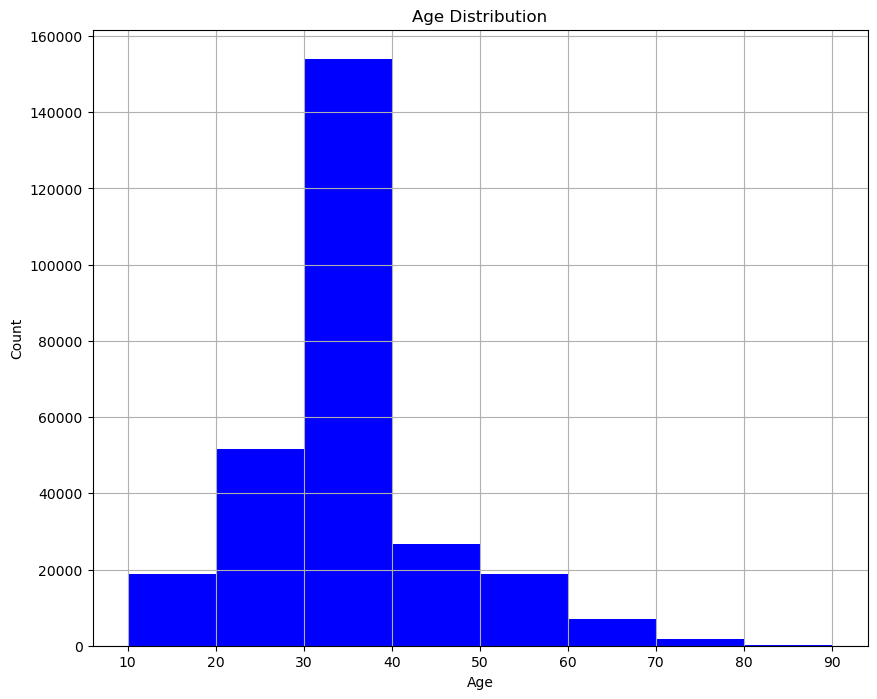

In [53]:
# age distributions of users_data
plt.figure(figsize=(10,8))
users_data.age.hist(bins=[10*i for i in range(1, 10)], color = 'blue')     
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [55]:
# find unique isbn from rating and books dataset
unique_ratings=ratings_data[ratings_data.isbn.isin(books_data.isbn)]
unique_ratings

,user_id,isbn,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149774,276704,0876044011,0
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10


In [57]:
print(ratings_data.shape)
print(unique_ratings.shape)

(1149780, 3)
(1031136, 3)


In [59]:
#unique rating value from 'book_rating' feature
unique_ratings['book_rating'].unique()

array([ 0,  5,  3,  6,  7,  9,  8, 10,  1,  4,  2], dtype=int64)

C:\Users\vijayababu\AppData\Local\Temp\ipykernel_15592\1016159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="book_title", palette = 'Accent',data= books_data, order=books_data['book_title'].value_counts().index[0:20])


Text(0.5, 1.0, 'Top 20 books as per number of ratings')

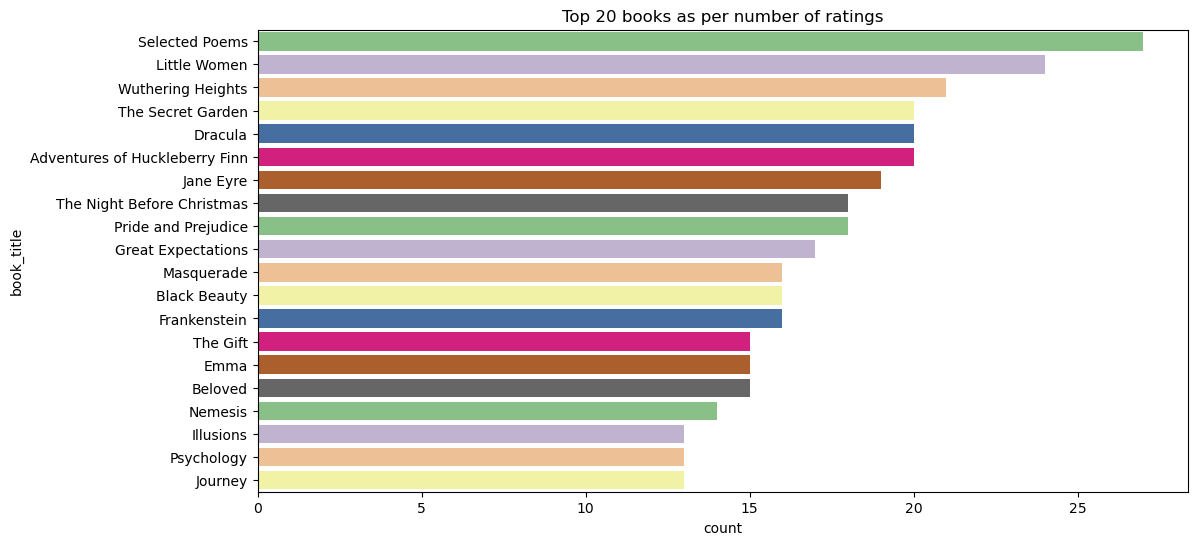

In [61]:
plt.figure(figsize=(12,6))
sns.countplot(y="book_title", palette = 'Accent',data= books_data, order=books_data['book_title'].value_counts().index[0:20])
plt.title("Top 20 books as per number of ratings")

C:\Users\vijayababu\AppData\Local\Temp\ipykernel_15592\1894481774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="book_rating",palette = 'Set2',data= unique_ratings)


<Axes: xlabel='book_rating', ylabel='count'>

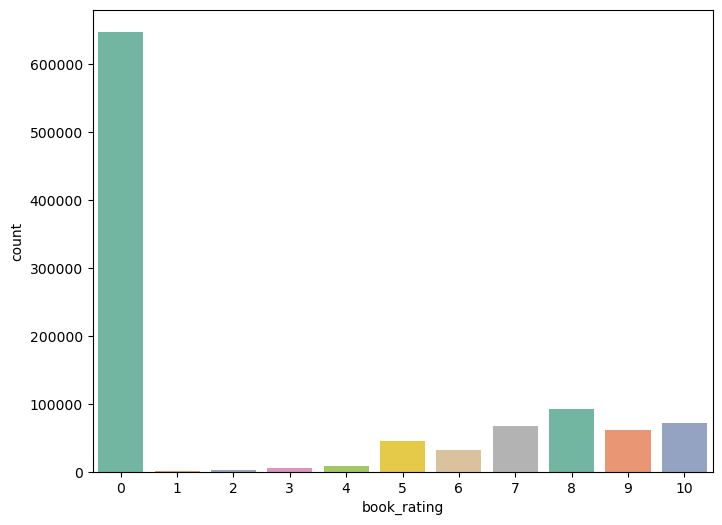

In [63]:
plt.figure(figsize=(8,6))
sns.countplot(x="book_rating",palette = 'Set2',data= unique_ratings)

C:\Users\vijayababu\AppData\Local\Temp\ipykernel_15592\404274201.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="book_rating",palette = 'Paired',data=rate_data)


Text(0.5, 1.0, 'Explicit Ratings')

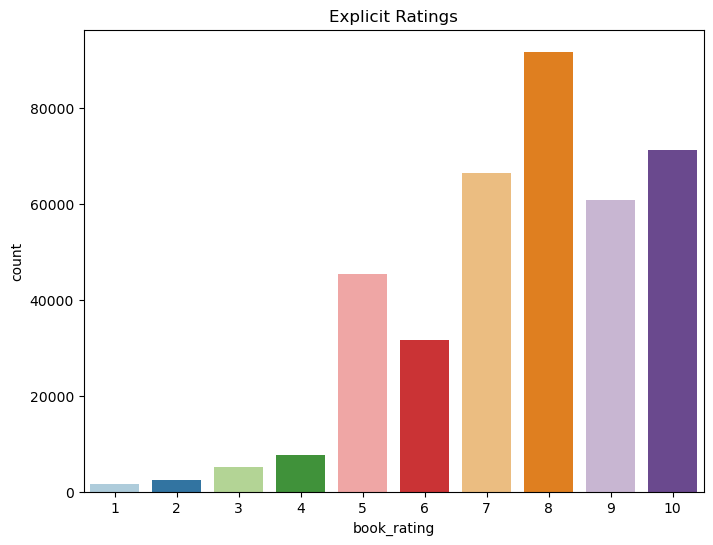

In [65]:
# Explicit Ratings
plt.figure(figsize=(8,6))
rate_data = unique_ratings[unique_ratings['book_rating'] != 0]
sns.countplot(x="book_rating",palette = 'Paired',data=rate_data)
plt.title("Explicit Ratings")

In [67]:
ratings_explicit= unique_ratings[unique_ratings['book_rating'] != 0]   # explicit ratings represented by 1–10
ratings_implicit= unique_ratings[unique_ratings['book_rating'] == 0]   # implicit ratings represented by 0
ratings_explicit.head()

,user_id,isbn,book_rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
8,276744,038550120X,7
16,276747,0060517794,9


In [69]:
print(unique_ratings.shape)
print(ratings_explicit.shape)

(1031136, 3)
(383842, 3)


In [71]:
# Merging books_data dataset and ratings_explicit
new_book_df= pd.merge(books_data, ratings_explicit, on='isbn')
new_book_df.head()

,isbn,book_title,book_author,year_of_publication,publisher,user_id,book_rating
0,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,8,5
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,11676,8
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,67544,8
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,116866,9
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,123629,9


In [73]:
print(new_book_df.shape)

(383842, 7)


In [75]:
new_book_df['book_title'].count()

383842

In [77]:
new_book_df['book_title'].nunique()

135567

In [79]:
# top ten books as per book ratings and recommendation
top_twenty_books= pd.DataFrame(new_book_df.groupby('book_title')['book_rating'].count()
                         .sort_values(ascending=False).head(20))
print('The top twenty books as per ratings : ')
top_twenty_books

The top twenty books as per ratings : 


,book_rating
book_title,
The Lovely Bones: A Novel,707
Wild Animus,581
The Da Vinci Code,494
The Secret Life of Bees,406
The Nanny Diaries: A Novel,393
The Red Tent (Bestselling Backlist),383
Bridget Jones's Diary,377
A Painted House,366
Life of Pi,336


In [81]:
#Memory based Collaborative filtering
from sklearn import model_selection
train_data, test_data = model_selection.train_test_split(new_book_df, test_size=0.20)

In [83]:
# Get int mapping for user_id in train dataset
u_unique_train = train_data.user_id.unique()  
train_data_user2idx = {o:i for i, o in enumerate(u_unique_train)}

# Get int mapping for isbn in train dataset
i_unique_train = train_data.isbn.unique()  
train_data_book2idx = {o:i for i, o in enumerate(i_unique_train)}

In [85]:
# Get int mapping for user_id in test dataset
u_unique_test = test_data.user_id.unique()  
test_data_user2idx = {o:i for i, o in enumerate(u_unique_test)}

# Get int mapping for isbn in test dataset
i_unique_test = test_data.isbn.unique() 
test_data_book2idx = {o:i for i, o in enumerate(i_unique_test)}

In [87]:
# training set
train_data['u_unique'] = train_data['user_id'].map(train_data_user2idx)
train_data['i_unique'] = train_data['isbn'].map(train_data_book2idx)

# testing set
test_data['u_unique'] = test_data['user_id'].map(test_data_user2idx)
test_data['i_unique'] = test_data['isbn'].map(test_data_book2idx)

# Convert back to three feature of dataframe 
train_data = train_data[['u_unique', 'i_unique', 'book_rating']]
test_data = test_data[['u_unique', 'i_unique', 'book_rating']]

In [89]:
train_data.sample(5)

,u_unique,i_unique,book_rating
178047,6697,40331,9
352892,59260,127532,9
129043,5758,33728,10
127718,1524,7811,8
226422,8239,38589,9


In [91]:
test_data.sample(5)

,u_unique,i_unique,book_rating
302809,1205,44704,1
29939,2757,3408,8
134091,716,803,8
30349,818,344,8
326617,20958,36142,6


In [93]:
#!pip install dask
from scipy.sparse import lil_matrix
# first I'll create an empty matrix of users books and then I'll add the appropriate values to the matrix by extracting them from the dataset
n_users = train_data['u_unique'].nunique()
n_books = train_data['i_unique'].nunique()

train_matrix = lil_matrix((n_users, n_books),dtype=np.float32)

chunk_size = 10000  # Define a chunk size that fits in memory
for start in range(0, len(train_data), chunk_size):
    chunk = train_data.iloc[start:start + chunk_size]
    for entry in chunk.itertuples():
        train_matrix[entry[1]-1, entry[2]-1] = entry[3]


In [94]:
train_matrix.shape

(59745, 128729)

In [95]:
n_users = test_data['u_unique'].nunique()
n_books = test_data['i_unique'].nunique()

test_matrix = np.zeros((n_users, n_books))

for entry in test_data.itertuples():
    test_matrix[entry[1]-1, entry[2]-1] = entry[3] 

In [99]:
test_matrix.shape

(25972, 46938)

In [101]:
# Cosine Similarity Based Recommendation System
train_matrix_small = train_matrix[:5000, :5000]
test_matrix_small = test_matrix[:5000, :5000]

from sklearn.metrics.pairwise import pairwise_distances
user_similarity = pairwise_distances(train_matrix_small, metric='cosine')
item_similarity = pairwise_distances(train_matrix_small.T, metric='cosine')

In [103]:
# function to predict the similarity :
def predict_books(ratings, similarity, type='user'): # default type is 'user'
    if type == 'user':
        # Convert sparse matrix to dense 
        ratings = ratings.toarray()  
        mean_user_rating = ratings.mean(axis=1)
        
        # Use np.newaxis so that mean_user_rating has the same format as ratings
        ratings_diff = (ratings - mean_user_rating[:, np.newaxis])
        pred = mean_user_rating[:, np.newaxis] + similarity.dot(ratings_diff) / np.array([np.abs(similarity).sum(axis=1)]).T
    elif type == 'item':
        ratings = ratings.toarray()  # Convert to dense for item-based prediction
        pred = ratings.dot(similarity) / np.array([np.abs(similarity).sum(axis=1)])
    return pred

In [105]:
item_prediction = predict_books(train_matrix_small, item_similarity, type='item')
user_prediction = predict_books(train_matrix_small, user_similarity, type='user')

In [107]:
# Evaluation metric by mean squared error
from sklearn.metrics import mean_squared_error
from math import sqrt

def rmse(prediction, test_matrix):
    prediction = prediction[test_matrix.nonzero()].flatten()
    test_matrix = test_matrix[test_matrix.nonzero()].flatten()
    return sqrt(mean_squared_error(prediction, test_matrix))

print(f'Item-based CF RMSE: {rmse(item_prediction, test_matrix_small)}')
print(f'User-based CF RMSE: {rmse(user_prediction, test_matrix_small)}')

Item-based CF RMSE: 7.943734790280486
User-based CF RMSE: 7.943768609417303


In [109]:
# Single Value decomposition model  to improve RMSE score
from surprise import SVD, Dataset, Reader, model_selection, accuracy

In [111]:
#import sys
#sys.executable

In [113]:
# Creating a 'Reader' object to set the limit of the ratings 
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings_explicit, reader)

In [120]:
model = SVD()
# Train on books dataset
%time model_selection.cross_validate(model, data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.6291  1.6286  1.6384  1.6441  1.6417  1.6364  0.0064  
Fit time          5.89    6.23    6.17    6.40    6.34    6.20    0.18    
Test time         0.49    0.90    0.80    0.49    0.93    0.72    0.19    
CPU times: total: 39.4 s
Wall time: 40.5 s


{'test_rmse': array([1.62914099, 1.6285987 , 1.63835326, 1.64411836, 1.6417352 ]),
 'fit_time': (5.887020826339722,
  6.233261823654175,
  6.165071964263916,
  6.403247356414795,
  6.33586859703064),
 'test_time': (0.491621732711792,
  0.8995728492736816,
  0.7965564727783203,
  0.49340271949768066,
  0.9340455532073975)}

In [121]:
# train and test split
trainset, testset = model_selection.train_test_split(data, test_size=0.2)

# SVD model
model = SVD()
model.fit(trainset)

In [128]:
# displaying RMSE score
predictions = model.test(testset)
print(f"The accuracy is {accuracy.rmse(predictions)}")

RMSE: 1.6401
The accuracy is 1.6400848420746774


In [130]:
# to test result let's take an user-id and item-id to test our model.
uid = 276744  
iid = '038550120X' 
pred = model.predict(uid, iid, verbose=True)

user: 276744     item: 038550120X r_ui = None   est = 7.68   {'was_impossible': False}


In [132]:
# display estimated rating and real rating
print(f'The estimated rating for the book with ISBN code {pred.iid} from user #{pred.uid} is {pred.est:.2f}.\n')
actual_rtg= ratings_explicit[(ratings_explicit.user_id==pred.uid) & 
                             (ratings_explicit.isbn==pred.iid)].book_rating.values[0]
print(f'The real rating given for this was {actual_rtg:.2f}.')

The estimated rating for the book with ISBN code 038550120X from user #276744 is 7.68.

The real rating given for this was 7.00.


In [134]:
# The following function was adapted from the surprise docs
# and can be used to get the top book recommendations for each user.
from collections import defaultdict

def get_top_n(predictions, n=10):
    
    # First map the predictions to each user
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
        
    return top_n


In [136]:
# prediciton on test set and getting top predictions
pred = model.test(testset)
top_n = get_top_n(pred)

In [137]:
pred_testset_df = pd.DataFrame(pred)
pred_testset_df

,uid,iid,r_ui,est,details
0,171082,1551666650,10.0,8.214163,{'was_impossible': False}
1,107784,0842338454,5.0,5.528890,{'was_impossible': False}
2,177458,0805022945,8.0,7.211443,{'was_impossible': False}
3,28591,0312303467,10.0,8.096651,{'was_impossible': False}
4,46909,0786014474,6.0,8.767632,{'was_impossible': False}
...,...,...,...,...,...
76764,98723,0684196395,8.0,7.656983,{'was_impossible': False}
76765,129008,0345438329,5.0,7.231967,{'was_impossible': False}
76766,170615,0385336195,7.0,7.498766,{'was_impossible': False}
76767,230776,0767904249,8.0,7.942021,{'was_impossible': False}


In [140]:
pred_testset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76769 entries, 0 to 76768
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   uid      76769 non-null  int64  
 1   iid      76769 non-null  object 
 2   r_ui     76769 non-null  float64
 3   est      76769 non-null  float64
 4   details  76769 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 2.9+ MB


In [142]:
# retriving full book titles from full 'books_users_ratings' dataframe
def get_reading_list(userid):
    
    reading_list = defaultdict(list)
    top_n = get_top_n(pred, n=10)
    for n in top_n[userid]:
        book, rating = n
        title = new_book_df.loc[new_book_df.isbn==book].book_title.unique()[0]
        reading_list[title] = rating
    return reading_list

In [144]:
#take a random look at user_id
example_reading_list = get_reading_list(userid=116866)
for book, rating in example_reading_list.items():
    print(f'{book}: {rating}')

Chaos: Making a New Science: 8.214803961490311
SHIPPING NEWS: 7.983060085516431
The Dinosaur Project: The Story of the Greatest Dinosaur Hunt Ever Mounted: 7.829945208060512
Landmarks in Western Science: From Prehistory to the Atomic Age: 7.829945208060512
The Complete Idiot's Guide to Javascript: 7.829945208060512
The Moscow Puzzles: 359 Mathematical Recreations: 7.829945208060512
Granta 52: Food : The Vital Stuff: 7.829945208060512
River Why: 7.829945208060512
Climbing Mount Improbable: 7.7972344227921635
The Man Who Tasted Shapes: A Bizarre Medical Mystery Offers Revolutionary Insights into Emotions, Reasoning, and Consciousness: 7.706972834149946


In [146]:
example_reading_list=get_reading_list(userid=274061)
for book, rating in example_reading_list.items():
    print(f'{book}: {rating}')

Savage Thunder: 10
Strangers: 10
Swan Song: 10
Silver on the Tree: 10
Charming the Prince: 10
Dark Desire (Paranormal Romance): 10
Riptide: 9.938293974510724
Magic Knight Rayearth 1: 9.811302980187254
The Magic of You (Malory Novels (Paperback)): 9.811069484563186
Clover (Clover, 1): 9.785417021900077


In [148]:
example_reading_list=get_reading_list(userid=10261)
for book, rating in example_reading_list.items():
    print(f'{book}: {rating}')

Moji milÃ­ SlovÃ¡ci: Listy rodÃ¡kom o nebezpecenstvÃ¡ch ktorÃ© im hrozia: 7.348364398458284


In [150]:
example_reading_list=get_reading_list(userid=215143)
for book, rating in example_reading_list.items():
    print(f'{book}: {rating}')

La Ley Del Amor: 8.695032283521654
Les Tribulations de Tiffany Trott: 8.28970663451829
